# 02 - Preprocesamiento: Filtrado, Segmentación, Normalización

**Fase del Pipeline DSR: Preparación de Datos**

Este notebook demuestra el pipeline de preprocesamiento de ECG:
1. Filtrado paso banda Butterworth (0.5-40 Hz)
2. Detección QRS y localización del pico R
3. Segmentación de latidos (200 muestras = 90 antes + 110 después del pico R)
4. Normalización Z-score por latido

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ecg_anomaly.config import SystemConfig
from ecg_anomaly.seeding import set_global_seed
from ecg_anomaly.data.loader import MITBIHLoader
from ecg_anomaly.preprocessing.filters import butterworth_bandpass
from ecg_anomaly.preprocessing.segmentation import segment_beats, normalize_beats
from ecg_anomaly.preprocessing.qrs_detection import pan_tompkins
from ecg_anomaly.preprocessing.pipeline import PreprocessingPipeline
from ecg_anomaly.visualization.signals import plot_raw_vs_filtered, plot_signal_with_peaks, plot_beat_overlay

sns.set_style("whitegrid")
config = SystemConfig.from_yaml("../config/default.yaml")
config.setup_logging()
set_global_seed(config.random_seed)

## 1. Cargar un Registro de Muestra

In [2]:
loader = MITBIHLoader(config)
dataset = loader.load(config.dataset_path, records=["100"])
record = dataset.records[0]

print(f"Registro {record.record_id}: {len(record.signal)} muestras a {record.sampling_rate} Hz")
print(f"Duracion: {len(record.signal) / record.sampling_rate:.1f} segundos")
print(f"Latidos anotados: {len(record.r_peak_positions)}")

15:04:46 [ecg_anomaly.data.loader] INFO: Cargados 1 registros: 2273 latidos (2239 normal, 34 anomalo)


Registro 100: 650000 muestras a 360 Hz
Duracion: 1805.6 segundos
Latidos anotados: 2273


## 2. Filtro Paso Banda Butterworth: Crudo vs Filtrado

El filtro paso banda (0.5-40 Hz, Butterworth 4to orden) elimina:
- Deriva de línea base (< 0.5 Hz)
- Ruido de alta frecuencia y artefactos EMG (> 40 Hz)

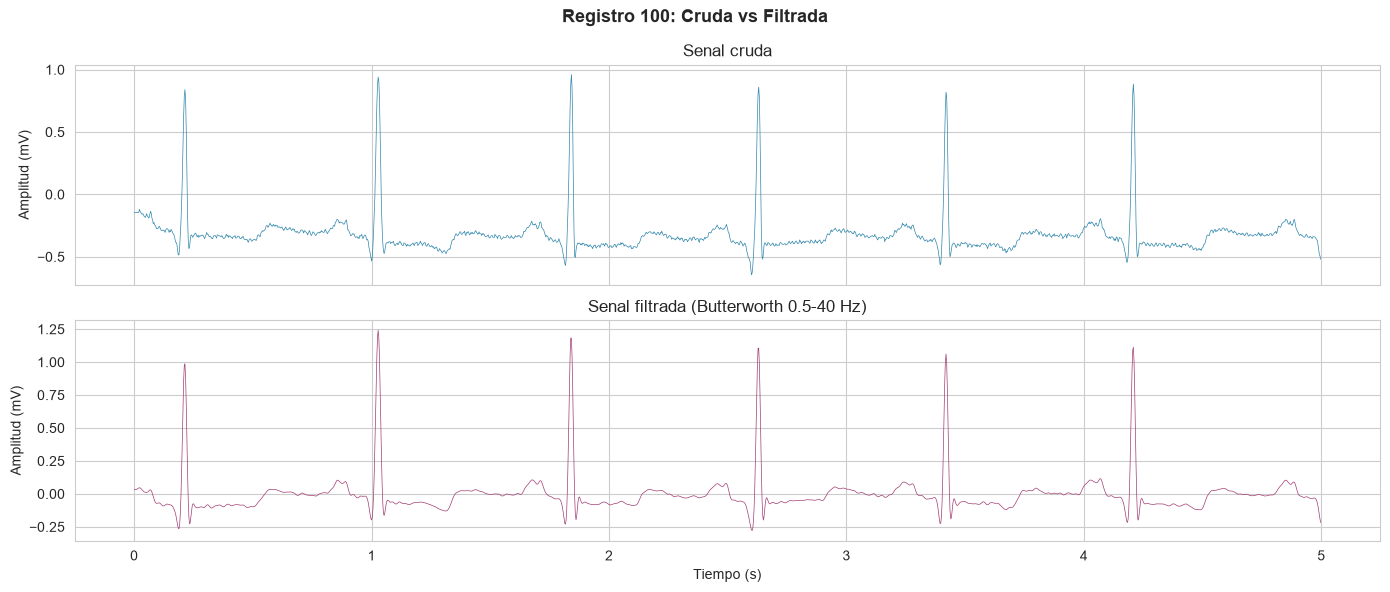

In [3]:
raw_signal = record.signal
filtered_signal = butterworth_bandpass(
    raw_signal,
    lowcut=config.filter_lowcut,
    highcut=config.filter_highcut,
    fs=config.sampling_rate,
    order=config.filter_order,
)

plot_raw_vs_filtered(
    raw_signal, filtered_signal,
    fs=config.sampling_rate,
    duration_seconds=5.0,
    title=f"Registro {record.record_id}: Cruda vs Filtrada",
)

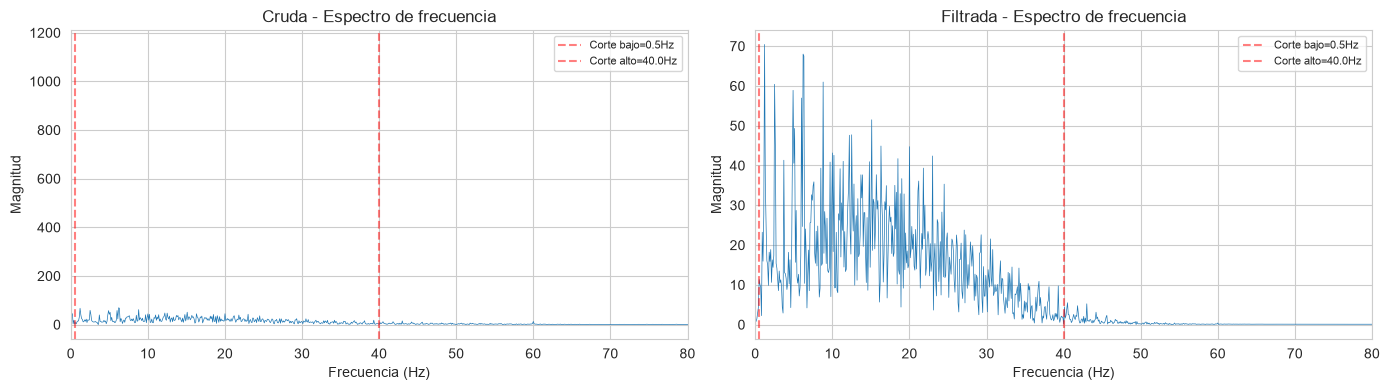

In [4]:
# Frequency domain comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, sig, title in [(axes[0], raw_signal, "Cruda"), (axes[1], filtered_signal, "Filtrada")]:
    fft_vals = np.abs(np.fft.rfft(sig[:config.sampling_rate * 10]))
    freqs = np.fft.rfftfreq(config.sampling_rate * 10, d=1.0/config.sampling_rate)
    ax.plot(freqs, fft_vals, linewidth=0.5)
    ax.set_xlim(0, 80)
    ax.set_xlabel("Frecuencia (Hz)")
    ax.set_ylabel("Magnitud")
    ax.set_title(f"{title} - Espectro de frecuencia")
    ax.axvline(config.filter_lowcut, color="r", linestyle="--", alpha=0.5, label=f"Corte bajo={config.filter_lowcut}Hz")
    ax.axvline(config.filter_highcut, color="r", linestyle="--", alpha=0.5, label=f"Corte alto={config.filter_highcut}Hz")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. Detección QRS y Localización del Pico R

MIT-BIH proporciona posiciones de picos R anotadas por expertos como verdad de campo.
**El pipeline de esta tesis utiliza exclusivamente estas anotaciones** en lugar de
redetectar QRS -- Pan-Tompkins no interviene en ningún resultado reportado en los
notebooks 03-05.

A continuación se muestra el detector Pan-Tompkins únicamente a modo de referencia
comparativa: sirve para ilustrar cuánto se desvía una detección algorítmica clásica
de la anotación experta en este dataset, lo cual justifica por qué el pipeline confía
en las anotaciones en vez de en un detector automático.

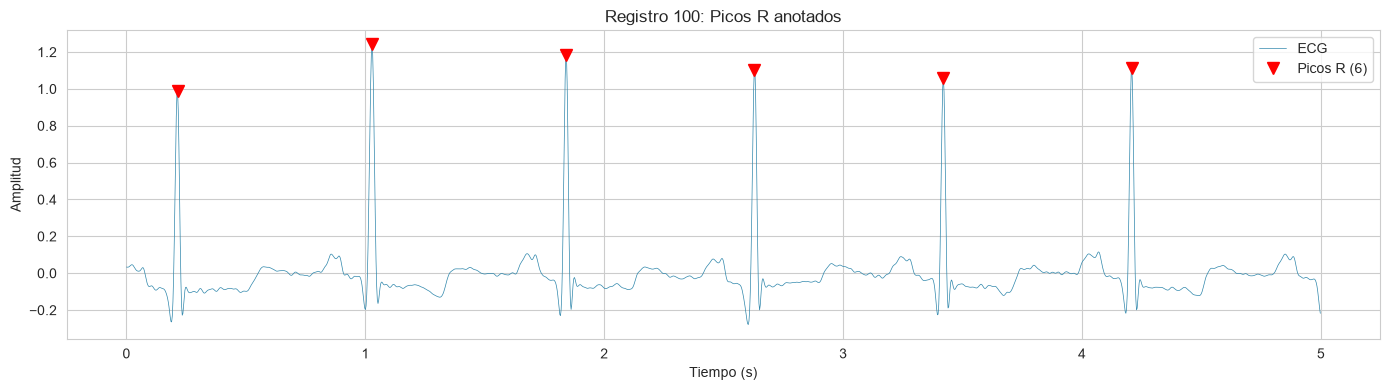

In [5]:
# Annotated R-peaks (ground truth)
plot_signal_with_peaks(
    filtered_signal,
    record.r_peak_positions,
    fs=config.sampling_rate,
    duration_seconds=5.0,
    title=f"Registro {record.record_id}: Picos R anotados",
)

Picos R anotados: 2273
Detectados por Pan-Tompkins: 2273


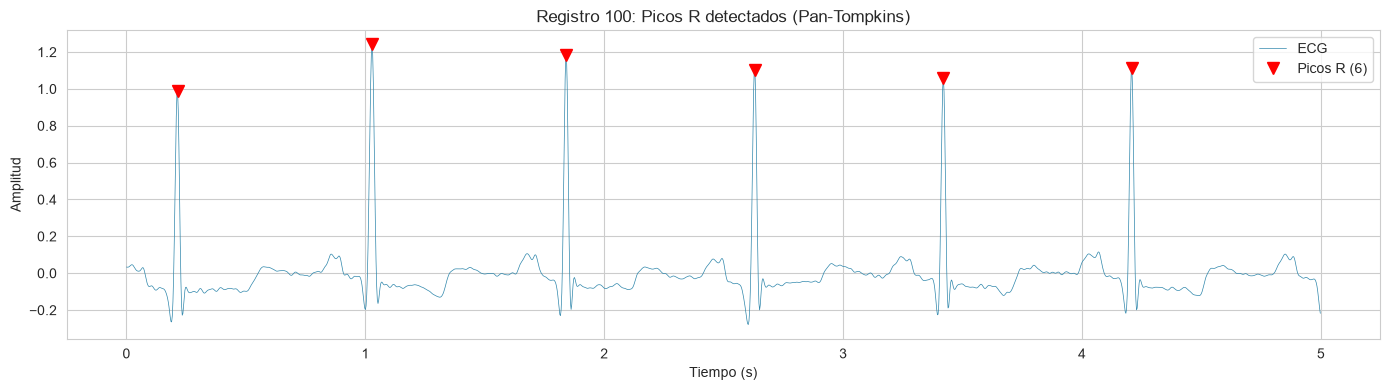

In [6]:
# Pan-Tompkins detection for comparison
detected_peaks = pan_tompkins(filtered_signal, fs=config.sampling_rate)
print(f"Picos R anotados: {len(record.r_peak_positions)}")
print(f"Detectados por Pan-Tompkins: {len(detected_peaks)}")

plot_signal_with_peaks(
    filtered_signal,
    detected_peaks,
    fs=config.sampling_rate,
    duration_seconds=5.0,
    title=f"Registro {record.record_id}: Picos R detectados (Pan-Tompkins)",
)

## 4. Segmentación de Latidos

Cada latido se extrae como una ventana de 200 muestras alrededor del pico R:
- **90 muestras antes** del pico R (~250 ms a 360 Hz)
- **110 muestras después** del pico R (~305 ms a 360 Hz)

Los latidos en los bordes de la señal donde la ventana se extendería más allá
de los límites de la grabación se descartan.

In [7]:
segments, valid_idx = segment_beats(
    filtered_signal,
    record.r_peak_positions,
    before=config.before_r_samples,
    after=config.after_r_samples,
)

print(f"Ventana de latido: {config.before_r_samples} + {config.after_r_samples} = {config.beat_length} muestras")
print(f"Picos R de entrada: {len(record.r_peak_positions)}")
print(f"Segmentos validos extraidos: {segments.shape[0]}")
print(f"Forma del segmento: {segments.shape}")

Ventana de latido: 90 + 110 = 200 muestras
Picos R de entrada: 2273
Segmentos validos extraidos: 2271
Forma del segmento: (2271, 200)


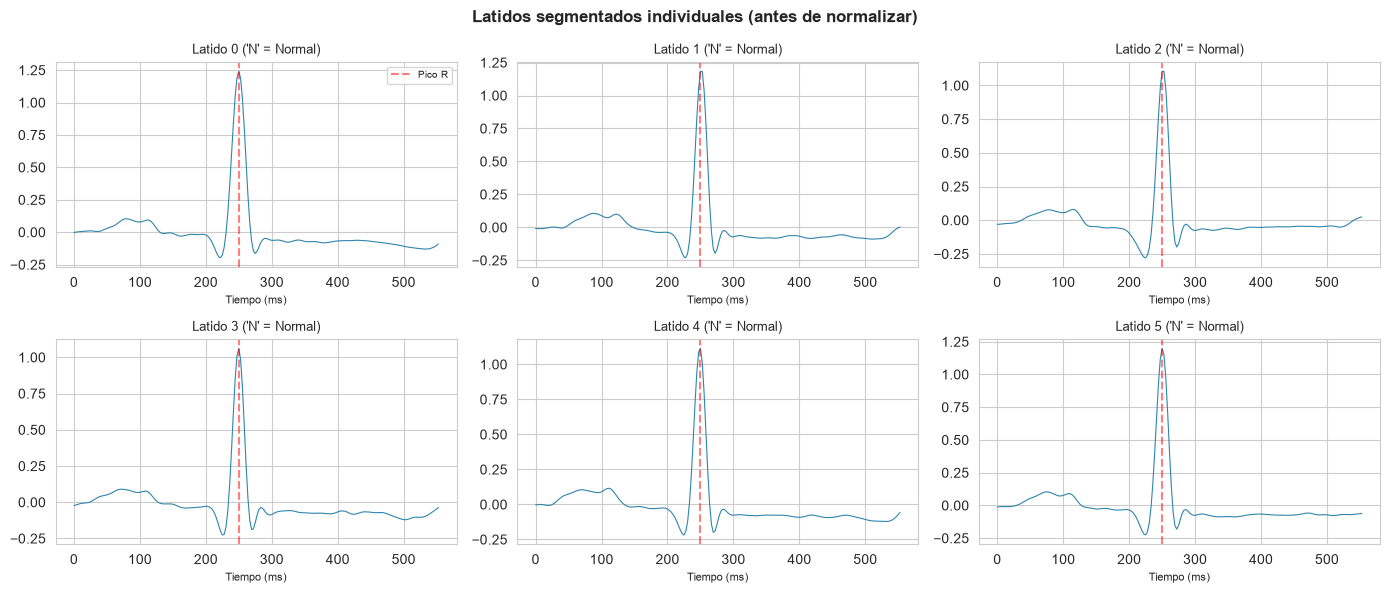

In [8]:
# Show individual segmented beats (before normalization)
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
t_ms = np.arange(config.beat_length) / config.sampling_rate * 1000

for i, ax in enumerate(axes.flat):
    ax.plot(t_ms, segments[i], color="#2E86AB", linewidth=0.8)
    ax.axvline(config.before_r_samples / config.sampling_rate * 1000, color="red",
               linestyle="--", alpha=0.5, label="Pico R")
    label = record.binary_labels[valid_idx[i]]
    symbol = record.symbols[valid_idx[i]]
    status = "Normal" if label == 0 else "Anomalo"
    ax.set_title(f"Latido {i} ('{symbol}' = {status})", fontsize=9)
    ax.set_xlabel("Tiempo (ms)", fontsize=8)

axes[0, 0].legend(fontsize=7)
plt.suptitle("Latidos segmentados individuales (antes de normalizar)", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Normalización Z-Score

Cada latido se normaliza independientemente a media cero y varianza unitaria.
Esto elimina diferencias de amplitud entre derivaciones y pacientes mientras
preserva la forma morfológica.

In [9]:
normalized = normalize_beats(segments)

print(f"Antes de normalizar - media: {segments[0].mean():.4f}, std: {segments[0].std():.4f}")
print(f"Despues de normalizar  - media: {normalized[0].mean():.6f}, std: {normalized[0].std():.4f}")

Antes de normalizar - media: 0.0061, std: 0.2218
Despues de normalizar  - media: 0.000000, std: 1.0000


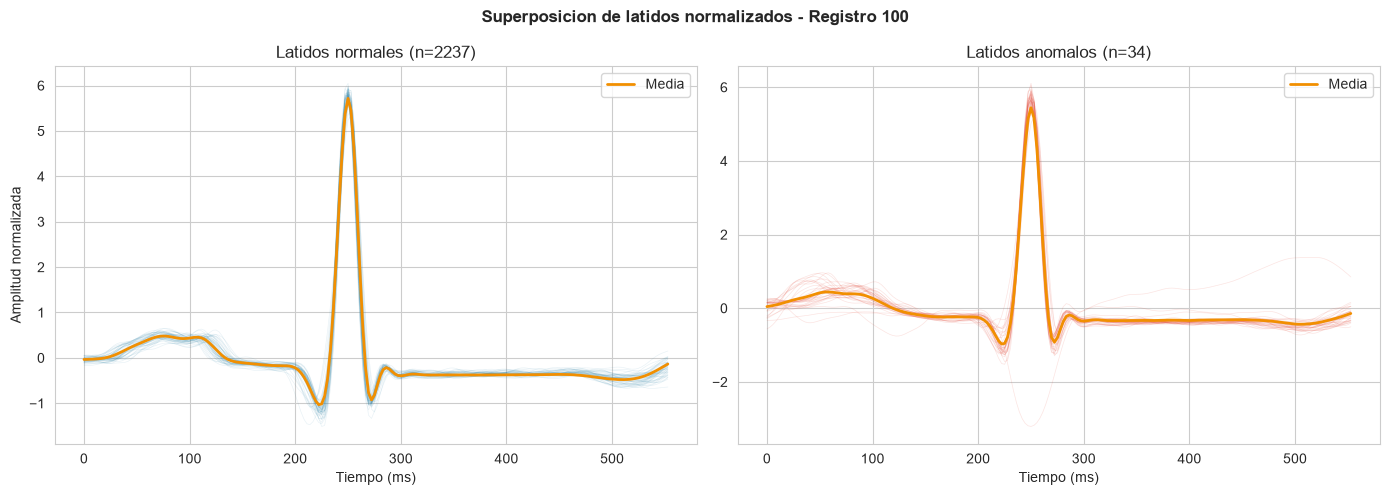

In [10]:
# Overlay normalized beats: normal vs anomalous
labels = record.binary_labels[valid_idx]
normal_mask = labels == 0
anomaly_mask = labels == 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal beats overlay
for i in np.where(normal_mask)[0][:50]:
    axes[0].plot(t_ms, normalized[i], alpha=0.1, color="#2E86AB", linewidth=0.5)
axes[0].plot(t_ms, normalized[normal_mask].mean(axis=0), color="#F18F01", linewidth=2, label="Media")
axes[0].set_title(f"Latidos normales (n={int(normal_mask.sum())})")
axes[0].set_xlabel("Tiempo (ms)")
axes[0].set_ylabel("Amplitud normalizada")
axes[0].legend()

# Anomalous beats overlay
if anomaly_mask.sum() > 0:
    for i in np.where(anomaly_mask)[0][:50]:
        axes[1].plot(t_ms, normalized[i], alpha=0.15, color="#E74C3C", linewidth=0.5)
    axes[1].plot(t_ms, normalized[anomaly_mask].mean(axis=0), color="#F18F01", linewidth=2, label="Media")
axes[1].set_title(f"Latidos anomalos (n={int(anomaly_mask.sum())})")
axes[1].set_xlabel("Tiempo (ms)")
axes[1].legend()

plt.suptitle(f"Superposicion de latidos normalizados - Registro {record.record_id}", fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Ejecución Completa del Pipeline

`PreprocessingPipeline` ejecuta todos los pasos (filtrar -> segmentar -> normalizar)
en todo el dataset en una sola llamada.

In [11]:
# Load full dataset and run pipeline
full_dataset = loader.load(config.dataset_path)
pipeline = PreprocessingPipeline(config)
preprocessed = pipeline.run(full_dataset)

print(f"Segmentos preprocesados: {preprocessed.segments.shape}")
print(f"Etiquetas: {preprocessed.labels.shape}")
print(f"Normal: {preprocessed.metadata['n_normal']:,}")
print(f"Anomalo: {preprocessed.metadata['n_anomalous']:,}")
print(f"Registros procesados: {preprocessed.metadata['n_records']}")

15:04:54 [ecg_anomaly.data.loader] INFO: Cargados 44 registros: 100733 latidos (90125 normal, 10608 anomalo)
15:04:55 [ecg_anomaly.preprocessing.pipeline] INFO: Preprocesamiento completo: 100705 latidos [100705, 200] (normal=90099, anomalo=10606)


Segmentos preprocesados: (100705, 200)
Etiquetas: (100705,)
Normal: 90,099
Anomalo: 10,606
Registros procesados: 44


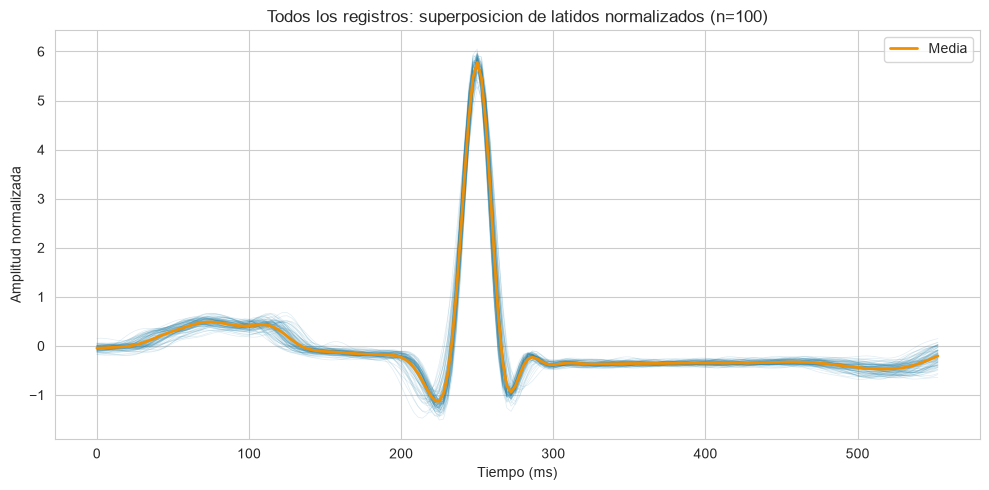

In [12]:
# Full dataset beat overlay
plot_beat_overlay(
    preprocessed.segments,
    n_beats=100,
    fs=config.sampling_rate,
    title="Todos los registros: superposicion de latidos normalizados",
)

## Resumen

El pipeline de preprocesamiento produce una matriz de forma `[N, 200]` donde cada
fila es un latido normalizado. Parámetros clave:
- Filtro paso banda: 0.5-40 Hz, Butterworth 4to orden
- Ventana de latido: 90 + 110 = 200 muestras (~555 ms a 360 Hz)
- Normalización: Z-score por latido

**Siguiente:** `03_feature_extraction.ipynb` -- reducción a componentes PCA o características manuales.